#### (주석) Cusor를 사용하여 다음과 같은 prompt로 진행을 하였습니다.

```
다음과 같은 미니프로젝트 B)를 수행하려고 합니다.

미니프로젝트 B) 비전 트레이닝: Appliance Vision Tuning (경량 VLM or Vision Classifier)
주제
스마트 생활가전 “상태 판독”용 비전 모델을 공개/더미 데이터로 튜닝
예: “필터 막힘(정상/오염)”, “문 열림(열림/닫힘)”, “성에(있음/없음)” 등
→ 최종 목표는 “제품에서 쓰는 방식(상태→권고)”을 체험.

목표
•	간단한 비전 모델(ResNet18/ViT-tiny) 또는 toy VLM 방식으로
o	데이터셋 구성(공개 + 약간의 더미/증강)
o	학습/평가 파이프라인 구축
o	결과를 제품형 JSON 출력(label, confidence, recommendation)으로 래핑
데이터 선택
아래 중 1개를 선택(추천은 1번)
1.	TrashNet / TACO 일부로 “이물질/먼지/종이/비닐” 분류 → 로봇청소기 흡입 위험물 판독(제품 시나리오에 잘 맞음)
2.	Open Images에서 “refrigerator/door” 관련 키워드로 소량 샘플링(여건 되면)
3.	완전 더미: 인터넷 공개 이미지 몇 장 + 증강

필수 산출물
•	train.ipynb (또는 train.py) : 학습/평가 재현 가능
•	데이터 설명: 클래스 정의, 샘플 수, 증강 전략
•	추론 함수: predict(image) -> {label, confidence, recommendation}
•	데모 10장 inference 결과(표 형태)
러프 가이드(진행 순서)
1.	문제 정의: 2~4클래스
2.	데이터 구성: train/val 분리, class imbalance 있으면 weight or sampling
3.	모델 선택: ResNet18(빠름) + 마지막 FC 교체
4.	학습: early stopping, lr scheduler(선택)
5.	평가: confusion matrix로 어떤 케이스가 헷갈리는지 설명
6.	제품형 래핑: label별 권고 문구(recommendation) 템플릿 작성

project2_vision 디렉토리에 코드를 작성하고
GUIDE.md 와 Project2_Appliance_Vision_Tuning_Skeleton.ipynb 를 참고하여 
train.ipynb 을 작성해줘
환경은 requirements2.txt를 사용하는데 
project2_vision 디렉토리에 .venv 가상환경을 사용하여 작성을 부탁해
```

# 미니프로젝트 B) Appliance Vision Tuning — 학습·평가·제품형 출력

**문제 정의:** 공기청정기/흡입 기기 **필터 상태** 2-class 분류 — `clean`(정상) vs `dirty`(오염 의심).

**데이터 설명**
- **출처:** 제공용 **합성(synthetic)** PNG (`data/images/...`). 저장소에 이미지가 없으면 아래 셀에서 `manifest.csv` 기준으로 자동 생성합니다.
- **클래스:** `clean` — 밝고 균일한 패턴 / `dirty` — 저휘도 배경 + 어두운 반점 패턴.
- **샘플 수 (manifest 기준):** train 24장(클래스 각 12), val 10장(클래스 각 5).
- **증강:** `RandomHorizontalFlip`, 학습용 `ColorJitter(brightness=0.2, contrast=0.2)` (경량 데이터에서 일반화 보조).
- **분리:** `manifest.csv`의 `split` 컬럼으로 train/val 고정.

**모델:** `ResNet18` + 마지막 `fc`를 2-class로 교체 (ImageNet 사전학습 가중치 초기화).

**산출물:** 학습 로그, validation accuracy, confusion matrix, val 10장 `predict()` 결과 표, `artifacts/filter_classifier.onnx`.

## 환경

`project2_vision/.venv` 가상환경을 활성화한 뒤, 루트의 `requirements2.txt`로 패키지를 설치하세요.

```bash
cd project2_vision
python -m venv .venv
.venv\Scripts\activate
pip install -r ..\requirements2.txt
```

아래 셀은 **패키지가 없을 때만** 한 번 실행하면 됩니다.

**참고:** `requirements2.txt`에 `vllm` 등이 포함되어 **Windows에서 전체 설치가 실패**할 수 있습니다. 이 노트북만 실행하려면 `torch`, `torchvision`, `pandas`, `pillow`, `matplotlib`, `tqdm`, `onnx`, `onnxruntime`이 있으면 됩니다. Jupyter에서 커널은 **이 `.venv`의 Python**을 선택하세요(`ipykernel` 설치 후 VS Code/Cursor에서 커널 지정). `import onnx` 시 DLL 오류가 나면 Visual C++ 재배포 패키지 설치를 확인하세요.

In [1]:
%pip install -r ../requirements2.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import hashlib
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
ARTIFACT_DIR = BASE_DIR / "artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)

manifest = pd.read_csv(DATA_DIR / "manifest.csv")
with open(DATA_DIR / "labels.json", "r", encoding="utf-8") as f:
    LABEL_JSON = json.load(f)

manifest.head()

,split,label,path
0,train,clean,images/train/clean/clean_00.png
1,train,clean,images/train/clean/clean_01.png
2,train,clean,images/train/clean/clean_02.png
3,train,clean,images/train/clean/clean_03.png
4,train,clean,images/train/clean/clean_04.png


In [3]:
def ensure_synthetic_images(manifest_df: pd.DataFrame, data_dir: Path, image_size: int = 64) -> None:
    """manifest에 적힌 경로가 없으면 합성 PNG를 생성합니다(재현 가능한 의사난수)."""
    for idx, row in manifest_df.iterrows():
        rel = row["path"]
        out_path = data_dir / rel
        if out_path.exists():
            continue
        out_path.parent.mkdir(parents=True, exist_ok=True)
        label = row["label"]
        dig = hashlib.md5(str(rel).encode("utf-8")).digest()
        seed = (int.from_bytes(dig[:4], "little") ^ (idx * 0x9E3779B9)) & 0xFFFFFFFF
        rng = np.random.default_rng(seed)
        arr = np.zeros((image_size, image_size, 3), dtype=np.uint8)
        if label == "clean":
            base = int(rng.integers(185, 230))
            arr[..., 0] = np.clip(base + rng.integers(-10, 10, size=(image_size, image_size)), 0, 255)
            arr[..., 1] = np.clip(base + rng.integers(-6, 14, size=(image_size, image_size)), 0, 255)
            arr[..., 2] = np.clip(base + rng.integers(-14, 6, size=(image_size, image_size)), 0, 255)
            noise = rng.integers(-12, 13, size=arr.shape, dtype=np.int16)
            arr = np.clip(arr.astype(np.int16) + noise, 0, 255).astype(np.uint8)
        else:
            base = int(rng.integers(55, 110))
            arr[..., :] = base
            spot_count = int(rng.integers(18, 40))
            for _ in range(spot_count):
                cx, cy = int(rng.integers(4, image_size - 4)), int(rng.integers(4, image_size - 4))
                r = int(rng.integers(3, 10))
                col = tuple(int(x) for x in rng.integers(8, 55, size=3))
                yy, xx = np.ogrid[:image_size, :image_size]
                mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r**2
                arr[mask] = col
            arr = np.clip(arr.astype(np.int16) + rng.integers(-18, 10, size=arr.shape, dtype=np.int16), 0, 255).astype(np.uint8)
        Image.fromarray(arr, mode="RGB").save(out_path)


ensure_synthetic_images(manifest, DATA_DIR)
print("이미지 준비 완료. 누락 시 합성 생성됨.")

이미지 준비 완료. 누락 시 합성 생성됨.


In [4]:
def set_seed(seed: int = 7) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Step 1. Dataset / Transform

#### (주석) 정규화는 `mean=std=0.5` (스켈레톤과 동일). 학습 split에만 색 증강을 추가합니다.

In [5]:
LABEL_TO_ID = {"clean": 0, "dirty": 1}
ID_TO_LABEL = {0: "clean", 1: "dirty"}
RECOMMENDATIONS = dict(LABEL_JSON)


def build_transforms(train: bool, image_size: int = 64):
    ops: list = [transforms.Resize((image_size, image_size))]
    if train:
        ops.append(transforms.RandomHorizontalFlip(p=0.5))
        ops.append(transforms.ColorJitter(brightness=0.2, contrast=0.2))
    ops.extend(
        [
            transforms.ToTensor(),
            transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
        ]
    )
    return transforms.Compose(ops)


class ApplianceVisionDataset(Dataset):
    def __init__(self, manifest_df: pd.DataFrame, split: str, image_size: int = 64):
        self.rows = manifest_df[manifest_df["split"] == split].reset_index(drop=True)
        self.transform = build_transforms(train=split == "train", image_size=image_size)

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index: int):
        row = self.rows.iloc[index]
        image = Image.open(DATA_DIR / row["path"]).convert("RGB")
        image = self.transform(image)
        label = LABEL_TO_ID[row["label"]]
        return image, label, row["path"]

## Step 2. 모델 (`build_model`)

#### (주석) `ResNet18` + `fc`를 2-class로 교체합니다.

In [6]:
def build_model(num_classes: int = 2) -> nn.Module:
    weights = models.ResNet18_Weights.IMAGENET1K_V1
    model = models.resnet18(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

## Step 3. 학습 / 평가 (`train_one_epoch`, `evaluate`)

#### (주석) `collect_predictions=True`이면 검증셋 전체 예측을 모아 confusion matrix에 사용합니다.

In [7]:
def train_one_epoch(model, loader, criterion, optimizer, device) -> float:
    model.train()
    running = 0.0
    n = 0
    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        bs = images.size(0)
        running += loss.item() * bs
        n += bs
    return running / max(n, 1)


@torch.no_grad()
def evaluate(model, loader, device, collect_predictions: bool = False):
    model.eval()
    correct = 0
    total = 0
    preds_list: list[int] = []
    labels_list: list[int] = []
    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = model(images)
        pred = logits.argmax(dim=1)
        correct += int((pred == labels).sum().item())
        total += int(labels.numel())
        if collect_predictions:
            preds_list.extend(pred.detach().cpu().tolist())
            labels_list.extend(labels.detach().cpu().tolist())
    acc = correct / total if total else 0.0
    if collect_predictions:
        return acc, preds_list, labels_list
    return acc

## Step 4. 학습 실행

- **Optimizer:** Adam, lr=`1e-3`
- **Scheduler:** `ReduceLROnPlateau`(검증 정확도 정체 시 lr 감소)
- **Early stopping:** 검증 정확도가 `patience` 에폭 동안 개선 없으면 중단

#### (주석) 클래스 비율이 균형이므로 `CrossEntropyLoss` 가중치 없이 사용합니다.

In [8]:
IMAGE_SIZE = 64
BATCH_SIZE = 8

train_dataset = ApplianceVisionDataset(manifest, split="train", image_size=IMAGE_SIZE)
val_dataset = ApplianceVisionDataset(manifest, split="val", image_size=IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("train:", len(train_dataset), "val:", len(val_dataset))

train: 24 val: 10


In [9]:
model = build_model(num_classes=2).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=2)

max_epochs = 40
patience = 6
best_acc = 0.0
best_state = None
stall = 0

for epoch in range(1, max_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_acc, val_pred, val_true = evaluate(model, val_loader, device, collect_predictions=True)
    scheduler.step(val_acc)
    lr = optimizer.param_groups[0]["lr"]
    print(f"epoch={epoch:02d} train_loss={train_loss:.4f} val_acc={val_acc:.4f} lr={lr:.2e}")
    if val_acc > best_acc + 1e-6:
        best_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        stall = 0
    else:
        stall += 1
        if stall >= patience:
            print(f"Early stopping at epoch {epoch} (best val_acc={best_acc:.4f})")
            break

if best_state is not None:
    model.load_state_dict(best_state)
model.to(device)
print("최종 best val_acc:", best_acc)

epoch=01 train_loss=0.3441 val_acc=1.0000 lr=1.00e-03
epoch=02 train_loss=0.1951 val_acc=1.0000 lr=1.00e-03
epoch=03 train_loss=0.0014 val_acc=0.5000 lr=1.00e-03
epoch=04 train_loss=0.0140 val_acc=0.9000 lr=5.00e-04
epoch=05 train_loss=0.0016 val_acc=1.0000 lr=5.00e-04
epoch=06 train_loss=0.0002 val_acc=1.0000 lr=5.00e-04
epoch=07 train_loss=0.0000 val_acc=1.0000 lr=2.50e-04
Early stopping at epoch 7 (best val_acc=1.0000)
최종 best val_acc: 1.0


## Step 5. Confusion matrix (검증셋)

#### (주석) 어떤 클래스가 서로 헷갈리는지 시각적으로 확인합니다.

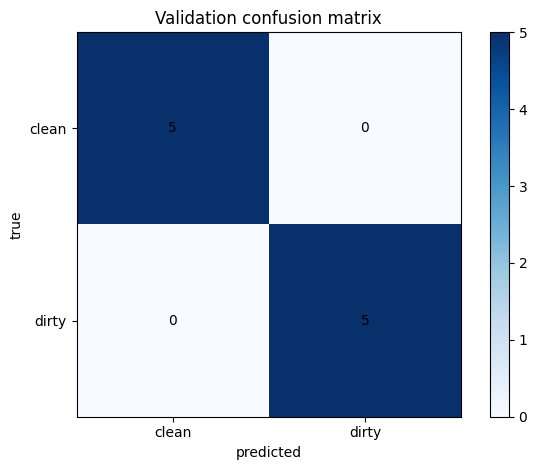

cm (rows=true, cols=pred):
 [[5 0]
 [0 5]]
이번 실행에서는 검증셋에서 오분류가 없습니다(소규모·합성 데이터).


In [10]:
import matplotlib.pyplot as plt


def confusion_matrix_np(y_true: list[int], y_pred: list[int], num_classes: int = 2) -> np.ndarray:
    cm = np.zeros((num_classes, num_classes), dtype=np.int64)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm


_, val_pred, val_true = evaluate(model, val_loader, device, collect_predictions=True)
cm = confusion_matrix_np(val_true, val_pred)
fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels([ID_TO_LABEL[i] for i in range(2)])
ax.set_yticklabels([ID_TO_LABEL[i] for i in range(2)])
ax.set_xlabel("predicted")
ax.set_ylabel("true")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, int(v), ha="center", va="center", color="black")
fig.colorbar(im, ax=ax)
ax.set_title("Validation confusion matrix")
plt.tight_layout()
plt.show()

print("cm (rows=true, cols=pred):\n", cm)
if cm[0, 1] or cm[1, 0]:
    print("오분류: clean→dirty 또는 dirty→clean 셀을 확인하세요.")
else:
    print("이번 실행에서는 검증셋에서 오분류가 없습니다(소규모·합성 데이터).")

## Step 6. 제품형 출력 `predict(image_path)`

#### (주석) 반환: `label`, `confidence`, `recommendation` (`data/labels.json`과 동기).

In [11]:
@torch.no_grad()
def predict(image_path: str | Path, model: nn.Module, image_size: int = 64) -> dict[str, object]:
    model.eval()
    path = Path(image_path)
    transform = build_transforms(train=False, image_size=image_size)
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    logits = model(tensor)
    probs = torch.softmax(logits, dim=1)[0]
    conf, pred_id = probs.max(dim=0)
    label = ID_TO_LABEL[int(pred_id.item())]
    return {
        "label": label,
        "confidence": float(conf.item()),
        "recommendation": RECOMMENDATIONS[label],
    }

## Step 7. 데모 10장 inference 표 (validation 전체)

In [12]:
val_paths = manifest[manifest["split"] == "val"]["path"].tolist()
assert len(val_paths) == 10, "manifest 기준 val 10장을 사용합니다."

demo_rows: list[dict] = []
for rel_path in val_paths:
    result = predict(DATA_DIR / rel_path, model, image_size=IMAGE_SIZE)
    demo_rows.append({"image_path": rel_path, **result})

demo_df = pd.DataFrame(demo_rows)
demo_df

,image_path,label,confidence,recommendation
0,images/val/clean/clean_00.png,clean,1.000000,필터 상태가 양호합니다. 정기 점검만 유지하세요.
1,images/val/clean/clean_01.png,clean,1.000000,필터 상태가 양호합니다. 정기 점검만 유지하세요.
2,images/val/clean/clean_02.png,clean,1.000000,필터 상태가 양호합니다. 정기 점검만 유지하세요.
3,images/val/clean/clean_03.png,clean,1.000000,필터 상태가 양호합니다. 정기 점검만 유지하세요.
4,images/val/clean/clean_04.png,clean,1.000000,필터 상태가 양호합니다. 정기 점검만 유지하세요.
5,images/val/dirty/dirty_00.png,dirty,0.999999,필터 오염 가능성이 높습니다. 청소 또는 교체를 권장합니다.
6,images/val/dirty/dirty_01.png,dirty,0.999997,필터 오염 가능성이 높습니다. 청소 또는 교체를 권장합니다.
7,images/val/dirty/dirty_02.png,dirty,0.999880,필터 오염 가능성이 높습니다. 청소 또는 교체를 권장합니다.
8,images/val/dirty/dirty_03.png,dirty,0.999985,필터 오염 가능성이 높습니다. 청소 또는 교체를 권장합니다.
9,images/val/dirty/dirty_04.png,dirty,0.970986,필터 오염 가능성이 높습니다. 청소 또는 교체를 권장합니다.


In [13]:
demo_csv = ARTIFACT_DIR / "demo_predictions.csv"
demo_df.to_csv(demo_csv, index=False)
print("저장:", demo_csv)

저장: /home/user/lecture/project2_vision/artifacts/demo_predictions.csv


## Step 8. ONNX export (`export_to_onnx`)

#### (주석) GUIDE 최소 통과: `artifacts/filter_classifier.onnx`

In [14]:
import onnx


def export_to_onnx(model: nn.Module, output_path: str | Path, image_size: int = 64) -> None:
    out = Path(output_path)
    out.parent.mkdir(parents=True, exist_ok=True)
    model_cpu = model.cpu().eval()
    dummy = torch.randn(1, 3, image_size, image_size)
    torch.onnx.export(
        model_cpu,
        dummy,
        str(out),
        input_names=["input"],
        output_names=["logits"],
        opset_version=17,
        dynamo=False,
    )
    onnx.checker.check_model(onnx.load(str(out)))
    model.to(device)


onnx_path = ARTIFACT_DIR / "filter_classifier.onnx"
export_to_onnx(model, onnx_path, image_size=IMAGE_SIZE)
print("ONNX OK:", onnx_path.resolve())

/tmp/ipykernel_83214/1740203427.py:9: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX OK: /home/user/lecture/project2_vision/artifacts/filter_classifier.onnx


## Bonus: `onnxruntime`로 동일 입력 검증 (선택)

In [15]:
import onnxruntime as ort

sample_rel = val_paths[0]
sample_pt = build_transforms(train=False, image_size=IMAGE_SIZE)(Image.open(DATA_DIR / sample_rel).convert("RGB")).unsqueeze(0).numpy()

sess = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
onnx_logits = sess.run([sess.get_outputs()[0].name], {sess.get_inputs()[0].name: sample_pt})[0]
with torch.no_grad():
    torch_logits = model(torch.from_numpy(sample_pt).to(device)).cpu().numpy()
print("logits max abs diff:", float(np.max(np.abs(onnx_logits - torch_logits))))

logits max abs diff: 4.76837158203125e-06
